In [1]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
import math
sys.path.append('../')
from Scattering_Simulator import pairwise_method
from Scattering_Simulator import Read_PDB
from genetic_algorithm import GA_functions as GA
from genetic_algorithm import curve_fitting as cf
from scipy import integrate
import torch

## Description

To fit the experimental data of the HuHF-PIX crystal, a model consisting of the ferratin cage arranged in a FCC crystal was used.

## Functions to import the protein structure 

In [2]:
def relative_coordinates(volume):
    '''This function is used to center any set of coordinates at the origin'''
    rel_x = volume[:,0] - np.mean(volume[:,0])
    rel_y = volume[:,1] - np.mean(volume[:,1])
    rel_z = volume[:,2] - np.mean(volume[:,2])
    relative_volume = np.hstack((rel_x.reshape(-1,1), rel_y.reshape(-1,1), rel_z.reshape(-1,1), volume[:,-1].reshape(-1,1)))
    return relative_volume


def extract_data(file_path):
    """
    Extract numeric data from a .dat file.
    Skips comment lines starting with # or non-numeric rows.
    Returns numpy array and pandas DataFrame.
    """

    data = []

    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()

            # Skip empty lines and comments
            if not line or line.startswith("#"):
                continue

            try:
                # Split by whitespace and convert to float
                row = [float(value) for value in line.split()]
                data.append(row)
            except ValueError:
                # Skip lines that can't be converted to float
                continue

    if not data:
        raise ValueError("No numeric data found in file.")

    data_array = np.array(data)

    # Create DataFrame with generic column names
    columns = [f"col_{i+1}" for i in range(data_array.shape[1])]
    df = pd.DataFrame(data_array, columns=columns)

    return data_array, df

## Functions used to fit the experimental data

In [168]:
def set_limits(parameters):
    '''This function converts the input parameters which range from 0 to 1 into the correct values
    used to create the sheet model. This is because the inputs and outputs of the genetic algoritm range from 0 to 1.
    '''
    upper = 200
    lower = 160
    d = parameters[0]*(upper - lower) + lower 
    upper = 3
    lower = 10
    size = int(np.round(parameters[1]*(upper - lower) + lower))
    upper = 4e-1
    lower = 8e-2
    background = parameters[2]*(upper - lower) + lower 
    upper = 5e-4
    lower = 5e-5
    scale = parameters[3]*(upper - lower) + lower 
    return d, size, background, scale


def generate_fcc_lattice(size, a):
    """
    Generate coordinates for a Face-Centered Cubic (FCC) lattice
    with random Gaussian displacements.

    Parameters
    ----------
    size : int or tuple of ints
        Number of unit cells in each direction.
    a : float
        Lattice constant.
    sigma : float
        Standard deviation of random displacement (same units as a).

    Returns
    -------
    coords : ndarray of shape (N, 3)
        Cartesian coordinates with disorder added.
    """
    sigma = 0 
    if isinstance(size, int):
        Nx = Ny = Nz = size
    else:
        Nx, Ny, Nz = size

    # FCC basis (fractional coordinates)
    basis = np.array([
        [0.0, 0.0, 0.0],
        [0.0, 0.5, 0.5],
        [0.5, 0.0, 0.5],
        [0.5, 0.5, 0.0]
    ])

    coords = []

    for i in range(Nx):
        for j in range(Ny):
            for k in range(Nz):
                cell_origin = np.array([i, j, k])
                for b in basis:
                    coords.append((cell_origin + b) * a)

    coords = np.array(coords)

    # Add isotropic Gaussian displacement
    displacement = np.random.normal(loc=0.0, scale=sigma, size=coords.shape)
    coords += displacement

    return coords

def invariant(data):
    '''Calculates the invariant'''
    q = data[:,0]
    I = data[:,1]
    invariant = integrate.simpson(q**2*I, q)
    return invariant

def objective_function(d, size, background, scale):
    '''This function creates the sheet model using the specified parameters and simulates its scattering curve
    Inputs:
    - d: separation distance between the proteins 
    - length: length of the sheet 
    - width: width of the sheet 
    - height: height of the sheet
    - distortion: random distortion of the protein in the height of the sheet 
    - monomer_proportion: proportion of unassembled monomers in the solution 
    - scale: arbitraty parameter used to scale the intensity curve 
    Outputs:
    - A 2D array with q and scattering intensity of the specified model 
    '''
    coordinates = Read_PDB.load_pdb_SANS('../Data/PDB/ferritin_pdb.pdb') 
    lattice_coords = generate_fcc_lattice(size, d)
    n_samples = 10000000
    simulator = pairwise_method.scattering_simulator(n_samples)
    histogram_bins = 10000
    q = np.geomspace(0.05, 0.4, 3000)
    I_q = simulator.simulate_scattering_curve_fast_lattice(coordinates, lattice_coords, histogram_bins, q).cpu()
    I_q_all = I_q*scale + background
    return np.hstack((q.reshape(-1,1), I_q_all.reshape(-1,1)))


def objective_function_multiple(d, size, background, scale):
    '''This function creates the sheet model using the specified parameters and simulates its scattering curve
    It is similar to the above function (objective_function), but the output scattering curve is simulated 10 times
    for better accuracy. 
    Inputs:
    - d: separation distance between the proteins 
    - length: length of the sheet 
    - width: width of the sheet 
    - height: height of the sheet
    - distortion: random distortion of the protein in the height of the sheet 
    - monomer_proportion: proportion of unassembled monomers in the solution 
    - scale: arbitraty parameter used to scale the intensity curve 
    Outputs:
    - A 2D array with q and scattering intensity of the specified model 
    '''
    coordinates = Read_PDB.load_pdb_SANS('../Data/PDB/ferritin_pdb.pdb') 
    lattice_coords = generate_fcc_lattice(size, d)
    n_samples = 10000000
    simulator = pairwise_method.scattering_simulator(n_samples)
    simulator.sample_building_block(coordinates)
    simulator.sample_lattice_coordinates(lattice_coords)
    simulator.calculate_structure_coordinates()

    histogram_bins = 10000
    q = torch.tensor(np.geomspace(0.05, 0.4, 3000))
    I_q = simulator.simulate_multiple_scattering_curves_lattice_coords(coordinates, lattice_coords, histogram_bins, q)
    I_q = I_q.cpu()
    I_q_mean = torch.mean(I_q[:,1:], dim=1)*scale + background
    return torch.cat((q.view(-1,1), I_q_mean.view(-1,1)), dim=1)


def convert_data(data, model):
    '''This function bins the model data so that it has the same number of data points as the experimental data
    inputs:
    - data: the experimental data with q and intensity as the two colums in the 2D array
    - model: the simulated data with q and intensity as the two columns in the 2D array
    output:
    - new_model_data: the binned model data with q and I as the two columns in the 2D array'''
    model_x = model[:,0]
    model_y = model[:,1]
    index = np.linspace(0, len(model_x)-1, len(model_x)) 
    model_q_new = []
    model_I_new = []
    for i in range(len(data)):
        data_q = data[i,0]
        array = np.abs(model_x - data_q)
        array = np.hstack((array.reshape(-1,1), index.reshape(-1,1)))
        array = array[np.argsort(array[:, 0])]
        loc = int(array[0,1])
        model_q_new.append(model_x[loc])
        model_I_new.append(model_y[loc])
    q = np.array(model_q_new).reshape(-1,1)
    I = np.array(model_I_new).reshape(-1,1)
    new_model_data = np.hstack((q, I))
    return new_model_data


def evaluate_obj_func(parameters, exp_data):
    '''This function evaluates the objective function and obtains a score for each set of input parameters
    inputs:
    - parameters: a 1D array of length 7 with each value corresponding to a structural parameter of the sheet model. These values range
    from 0 to 1 and are obtain from the genetic algorithm
    exp_data: the experimental data of the sheet structure
    outputs:
    - error: The score between the scattering curve of the model and the experimental data'''
    d, size, background, scale = set_limits(parameters)
    sim_data = objective_function_multiple(d, size, background, scale)
    sim_data = convert_data(exp_data, sim_data)
    plt.rcParams.update({'font.size': 22})
    #fig, ax = plt.subplots(figsize=(7,7))
    plt.ylabel('Intensity (arb. unit)')
    plt.xlabel('q ($\\AA^{-1}$)')
    plt.xscale('log')
    plt.yscale('log')
    plt.plot(sim_data[:,0], sim_data[:,1])
    plt.plot(exp_data[:,0], exp_data[:,1], linewidth=3, color ='k')
    error = np.mean(np.abs(np.log10(np.abs(exp_data[:,1])) - np.log10(np.abs(sim_data[:,1]))))
    return -error

def evaluate_obj_func_loop(x, exp_data):
    '''This function evaluates the objective function in a loop and obtains a score for each set of input parameters
    inputs:
    - x: a 2D array of columns 7 and as many rows with each column corresponding to a structural parameter of the sheet model. Each row represents
    a different candidate. All values range from 0 to 1 and are obtain from the genetic algorithm
    outputs:
    - y: an array of scores between the scattering curve of the model and the experimental data'''
    for i in range(x.shape[0]): # This is a loop that runs the test function for each row of an array
        y_row = evaluate_obj_func(x[i,:], exp_data)
        if i == 0:
            y = y_row
        else:
            y = np.vstack((y, y_row))
    return y

def run_optimization(exp_data, batch_size, mutation_rate, iterations):
    '''This function runs the genetic optimizer
    inputs:
    - exp_data: experimental data of the sample
    - batch_size: number of samples in each iteration
    - mutation_rate: controls exploration vs exploitation of the GA
    - iterations: number of iterations to run
    outputs:
    - alg.best_solution(): the best solution found in the optimization 
    - alg.max_fitness_lst: the history of the best scores at each iteration 
    '''
    x = np.random.rand(batch_size, 4)
    y = evaluate_obj_func_loop(x, exp_data)
    alg = GA.genetic_algorithm(batch_size, mutation_rate)
    for i in range(iterations):
        x = alg.run(x,y)
        y = evaluate_obj_func_loop(x, exp_data)
    return alg.best_solution(), alg.max_fitness_lst

## Importing the atomic coordinates of the ferritin cage protein

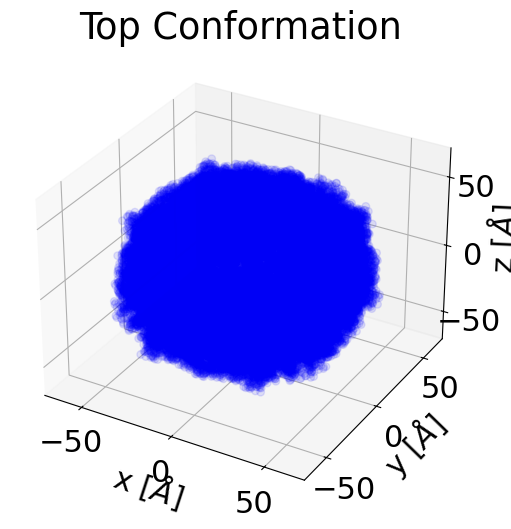

In [169]:
coordinates = Read_PDB.load_pdb_SANS('../Data/PDB/ferritin_pdb.pdb') 
coordinates = relative_coordinates(coordinates)
# Plotting
fig = plt.figure(figsize=(6,6))
ax = plt.axes(projection='3d')
ax.scatter(coordinates[:,0],coordinates[:,1],coordinates[:,2], color = 'blue', alpha = 0.1, s = 30)
ax.set_xlabel('x [$\\AA$]')
ax.set_ylabel('y [$\\AA$]')
ax.set_zlabel('z [$\\AA$]')
ax.set_title('Top Conformation')
building_block = coordinates

## Importing and plotting the experimental data

Text(0.5, 0, 'q ($\\AA^{-1}$)')

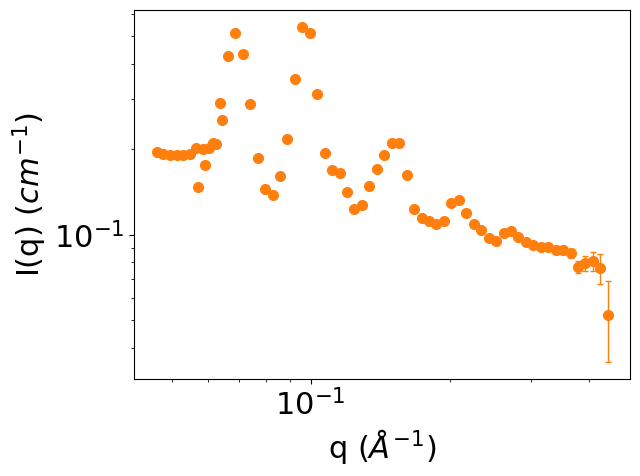

In [166]:
exp_data = extract_data('../Data/ferritin/2a_PIX_crystalline_I(q).txt')[0][70:]
plt.errorbar(
    exp_data[:,0], exp_data[:,1],
    yerr=exp_data[:,2],
    fmt='o',
    markersize=7,
    capsize=2,
    elinewidth=1,
    color = 'C1',
    ecolor='C1',
    zorder=0
)
plt.yscale('log')
plt.xscale('log')
plt.ylabel('I(q) ($cm^{-1}$)')
plt.xlabel('q ($\\AA^{-1}$)')

## Run the Fitting Algorithm 
The fitting algorithm is a genetic algorithm. The batch_size, mutation_rate, and iterations are optimization parameters. 

C:\Users\htchi\AppData\Local\Temp\ipykernel_27640\2434183522.py:146: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  array = np.abs(model_x - data_q)


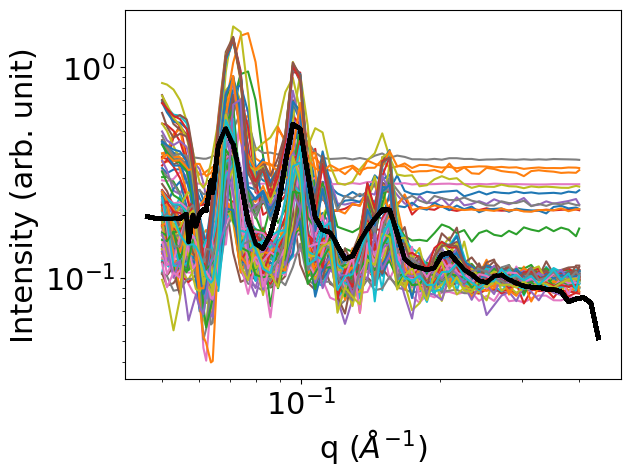

In [172]:
batch_size = 10
mutation_rate = 0.15
iterations = 10
best_solution, max_fitness_lst = run_optimization(exp_data, batch_size, mutation_rate, iterations)

## Check the best score at each iteration (closer to 0 is a better fit)

Text(0, 0.5, 'Score')

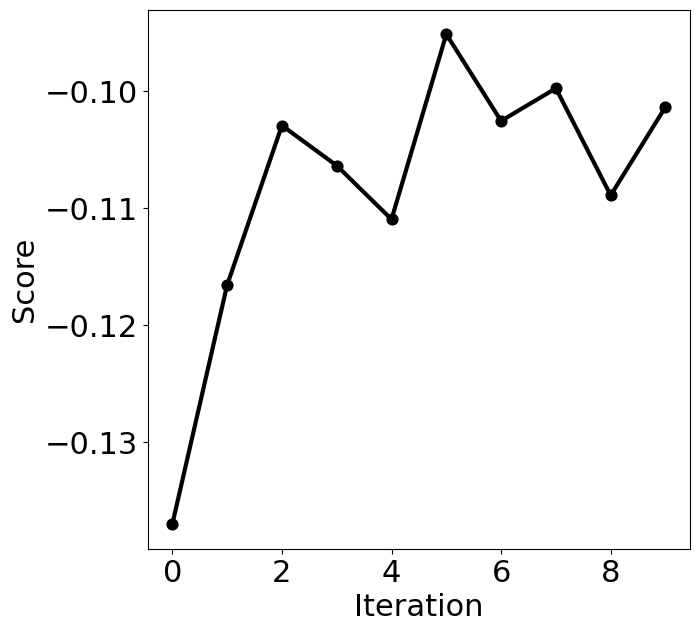

In [173]:
fig, ax = plt.subplots(figsize=(7,7))
itr = np.arange(0,iterations)
plt.plot(itr, max_fitness_lst, linewidth = 3, color='k')
plt.scatter(itr, max_fitness_lst, s = 60, color ='k')
plt.xlabel('Iteration')
plt.ylabel('Score')
#plt.savefig('../Images/RhuA/Sheets_Score_5.png', dpi=600, bbox_inches="tight")

## Extract the best fit parameters and plot the data

In [174]:
values = set_limits(best_solution)
print('d: ', values[0])
print('size: ',values[1])
print('background: ',values[2])
print('scale: ',values[3])


d:  181.36
size:  8
background:  0.10752
scale:  0.00048695


In [175]:
#best_fit = objective_function(values[0], values[1], values[2], values[3])
best_fit = objective_function_multiple(values[0], values[1], values[2], values[3])
# best_fit = torch.mean(best_fit, dim=1)

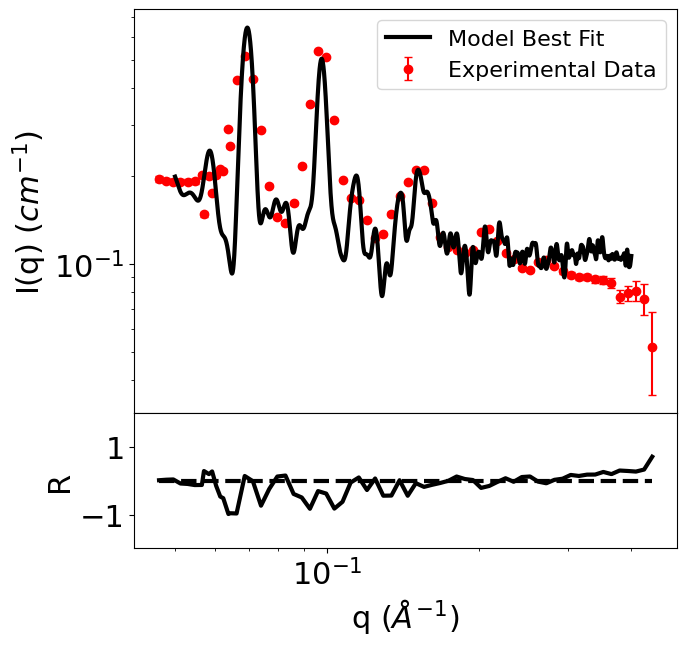

In [ ]:
plt.rcParams.update({'font.size': 22})
fig, ax = plt.subplots(figsize=(7,7), ncols = 1, nrows=2,  gridspec_kw={'height_ratios': [3, 1]})
q =np.geomspace(0.05, 0.4, 3000)
ax[0].errorbar(exp_data[:,0], exp_data[:,1], yerr=exp_data[:,2], label = 'Experimental Data', color = 'red', capsize=3, fmt='o', zorder=0)
ax[0].plot(best_fit[:,0], best_fit[:,1], color = 'k', linewidth=3, label = 'Model Best Fit')
#ax[0].errorbar(q, simulated_data, color='k', linewidth=3, label = 'Model Best Fit')
ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[0].set_ylabel('I(q) ($cm^{-1}$)')
#ax[0].grid()

ax[0].legend(fontsize=16)
plt.subplots_adjust(hspace=0)

model_data = cf.convert_data(exp_data, np.hstack((q.reshape(-1,1), best_fit[:,1].reshape(-1,1))))

model_residual = (np.log(model_data[:,1]/exp_data[:,1]))

ax[1].plot(exp_data[:,0], model_residual, color ='k', linewidth = 3)
ax[1].set_ylim([-2,2])
ax[1].set_yticks([-1,1])
ax[1].set_xscale('log')
ax[1].set_ylabel('R')
ax[1].hlines(0, np.min(exp_data[:,0]), np.max(exp_data[:,0]), color='k', linewidth=3, linestyle='--')
ax[1].set_xlabel('q ($\\AA^{-1}$)')

#plt.savefig('../Images/Ferritin_crystal.png', dpi=600, bbox_inches="tight")



In [ ]:
# np.savetxt(
#     "../Data/ferritin/simulated_ferratin_crystal.txt",
#     best_fit,
#     header="q  I(q)",
#     comments="",
#     fmt="%.6e"
# )